# Edge IIoT - Binary Classification


In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import Filters, Utils, Resamplers

from src.config import DATASETS, SEED
dataset_name = "edge_iiot"
config = DATASETS[dataset_name]

print("\n--- Dataset Information ---")
print(f"Name: {dataset_name.upper()}")
print(f"Path: {config['processed_path']}\n")

filename = "ML-EdgeIIoT-dataset_clean"

csv_path = config['processed_path'] / f"{filename}.pkl"
print(f"CSV Path: {csv_path}\n")

print("Loading dataset... (This may take a while)")
df = pd.read_pickle(csv_path)

print(f"\nDataset loaded with shape: {df.shape}")


--- Dataset Information ---
Name: EDGE_IIOT
Path: /home/uo294319/ML-NIDS-IIoT/data/edge_iiot/processed

CSV Path: /home/uo294319/ML-NIDS-IIoT/data/edge_iiot/processed/ML-EdgeIIoT-dataset_clean.pkl

Loading dataset... (This may take a while)

Dataset loaded with shape: (152591, 62)


## 1. Pre-processing

In [3]:
from sklearn.pipeline import Pipeline

preprocessing_pipeline = Pipeline([
    ("filter_invalid_time", Filters.ValidTimeFilter()),
    ("drop_categorical",    Filters.CategoricalDropper()),
    ("train_test_split",    Utils.TrainTestSplitter()),
    ("SMOTE",               Resamplers.SMOTEResampler()),
    ("shuffle",             Utils.Shuffler()),
    ('xysplit',             Utils.SplitExtractor())
])

X_train, X_test, y_train, y_test, _, _ = preprocessing_pipeline.fit_transform(df)

  [ValidTimeFilter] Dropped 15,526 rows  →  (137065, 62)
  [CategoricalDropper] Dropped 7 categorical columns: ['http.file_data', 'http.referer', 'http.request.path', 'http.request.uri.query', 'http.request.version', 'mqtt.msg', 'proto']  →  (137065, 55)
  [TrainTestSplitter] Train: 109,652  |  Test: 27,413
  [SMOTEResampler] Majority: 'Normal' (19,441)  → target minority size: 2,916
  [SMOTEResampler] Resampled train: 111,767
  [Shuffler] train: (111767, 55)
  [Shuffler] test: (27413, 55)
  [SplitExtractor] X_train: (111767, 53)  |  X_test: (27413, 53)  |  y_bin_train: (111767,) | y_15c_train: (111767,) | y_bin_test: (27413,) | y_15c_test: (27413,)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2. Model Tuning: ExtraTreesClassifier
Train and tune an Extra Trees Classifier using RandomizedSearchCV.

In [5]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import RandomizedSearchCV
import time

print("Setting up RandomizedSearchCV for ExtraTreesClassifier...")

# Baseline model
rf_base = ExtraTreesClassifier(
    random_state=SEED,
    n_jobs=-1,
    
)

# Parameter grid
param_grid = {
    'n_estimators': [50, 100, 200, 300],         # Number of trees in the forest.
    'max_depth': [None, 10, 20, 30],             # Maximum depth of the trees.
    'min_samples_split': [2, 5, 10],             # Minimum number of samples required to split an internal node.
    'min_samples_leaf': [1, 2, 4],               # Minimum number of samples required to be at a leaf node.
    'max_features': ['sqrt', 'log2', None]       # Number of features to consider when looking for the best split.
}

# Setup randomized search (n_iter=10 means it will randomly try 10 combinations)
rf_random = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=param_grid, 
    n_iter=10, 
    cv=3, 
    verbose=2, 
    random_state=SEED, 
    n_jobs=-1,
    scoring='f1_weighted'
)

start_time = time.time()
print("Starting hyperparameter tuning... (This might take a few minutes)")
rf_random.fit(X_train_scaled, y_train)
train_time = time.time() - start_time

print(f"\nHyperparameter tuning completed in {train_time:.2f} seconds.")
print(f"Best parameters found:\n{rf_random.best_params_}")

# Override rf_clf with the best model found so evaluation continues to work
rf_clf = rf_random.best_estimator_


Setting up RandomizedSearchCV for ExtraTreesClassifier...
Starting hyperparameter tuning... (This might take a few minutes)
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=  10.0s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=  11.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=  11.4s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=  12.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=  12.7s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=  25.4s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators

## 3. Evaluation
Evaluate the model's performance on the test set.

Evaluating model on test data...

--- Overall Metrics ---
Accuracy: 0.996206
ROC AUC Score: 0.999868

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4860
           1       1.00      1.00      1.00     22553

    accuracy                           1.00     27413
   macro avg       0.99      0.99      0.99     27413
weighted avg       1.00      1.00      1.00     27413



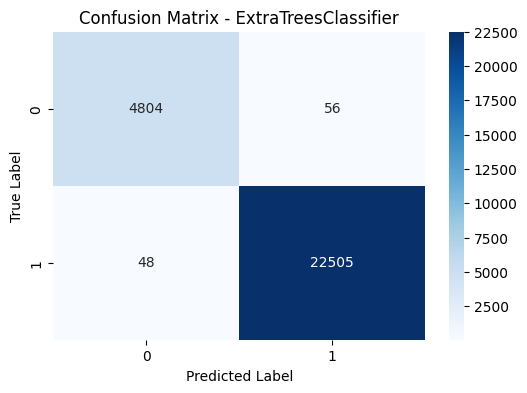

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

print("Evaluating model on test data...")
y_pred = rf_clf.predict(X_test_scaled)
y_prob = rf_clf.predict_proba(X_test_scaled)[:, 1] if hasattr(rf_clf, "predict_proba") else y_pred

print("\n--- Overall Metrics ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.6f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.6f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ExtraTreesClassifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


## 4. Feature Importance
Visualize the top features driving the predictions.

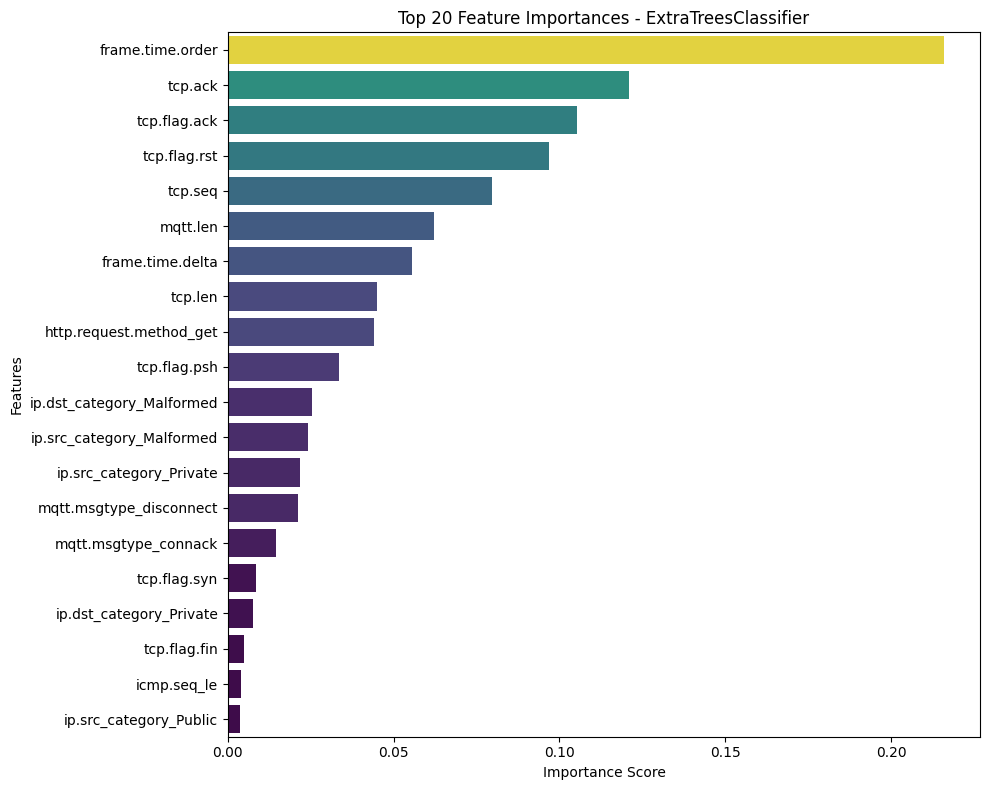

In [7]:
feature_names = X_test.columns
importances = rf_clf.feature_importances_

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', hue='Importance', data=fi_df, palette='viridis', legend=False)
plt.title('Top 20 Feature Importances - ExtraTreesClassifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


## 5. Explainable AI (SHAP)
Understand how the model makes its decisions using SHAP (SHapley Additive exPlanations).

In [8]:
import shap
shap.initjs()

# Sample size
n_sample = 5000 
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Stratified sampling
if X_test_scaled_df.shape[0] > n_sample:
    X_sample, _, y_sample, _ = train_test_split(
        X_test_scaled, 
        y_test, 
        train_size=n_sample, 
        random_state=SEED, 
        stratify=y_test
    )
else:
    X_sample = X_test_scaled_df.copy()
    y_sample = y_test.copy()

print(f"Extracted {X_sample.shape[0]} stratified observations for SHAP calculation.")
print(f"Class distribution in SHAP sample:\n{y_sample.value_counts(normalize=True).to_string()}")


Extracted 5000 stratified observations for SHAP calculation.
Class distribution in SHAP sample:
Attack_label
1    0.8228
0    0.1772


In [11]:
explainer = shap.TreeExplainer(rf_clf)
shap_obj = explainer(X_sample)

# Handle the output dimensionality depending on objective function (binary vs multiclass)
if len(shap_obj.shape) == 3:
    plot_obj = shap_obj[:, :, 1] # Extract positive class for binary classification
else:
    plot_obj = shap_obj

plot_obj.feature_names = list(X_test.columns)

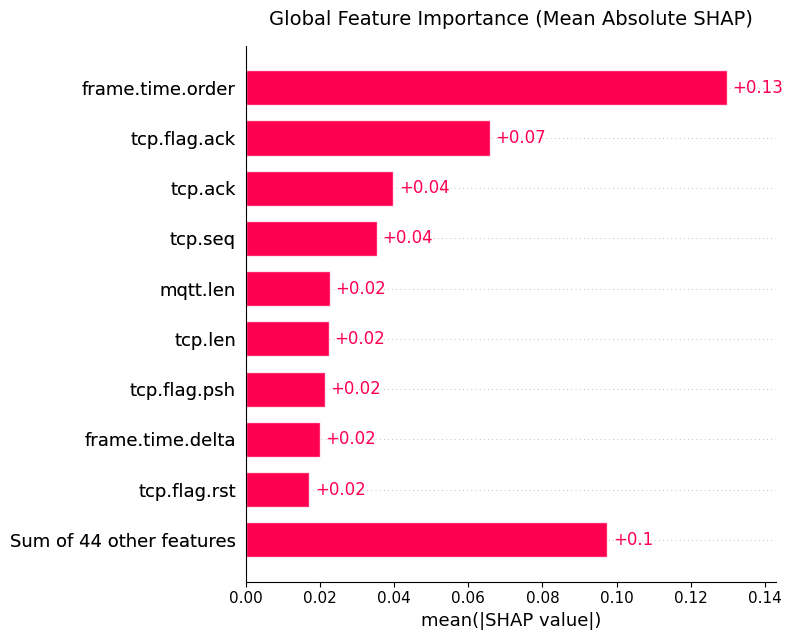

In [12]:
# Plot 1: Global Bar Plot (Mean Absolute SHAP)
plt.figure(figsize=(16, 6))
shap.plots.bar(plot_obj, max_display=10, show=False, )
plt.title("Global Feature Importance (Mean Absolute SHAP)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

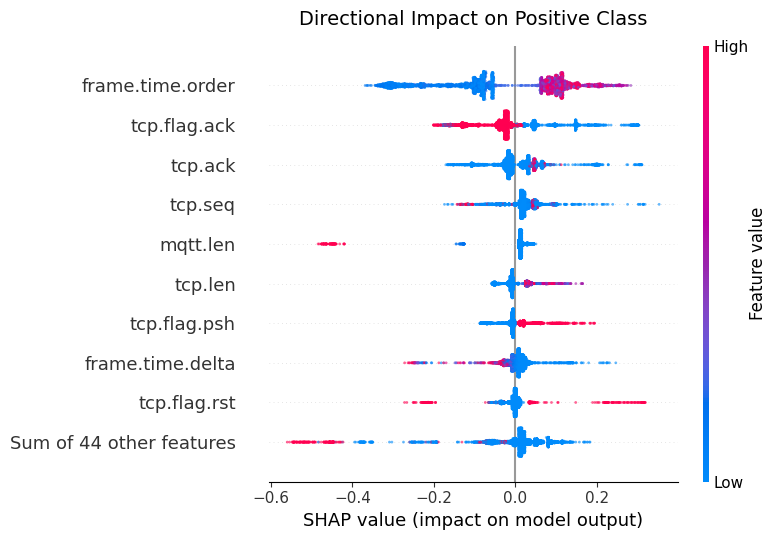

In [13]:
# Plot 2: Beeswarm Plot (Directional Impact)
plt.figure(figsize=(16, 6))
shap.plots.beeswarm(
    plot_obj, 
    max_display=10, 
    s=4,
    alpha=0.6,
    show=False
)
plt.title("Directional Impact on Positive Class", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## 6. Save Model
Save the trained model and scaler for reproducibility and results aggregation.

In [14]:
import joblib

model_path = config['bin_model_path'] / 'exp1'
model_path.mkdir(parents=True, exist_ok=True)

joblib.dump(rf_clf, model_path / 'model_et.pkl')
joblib.dump(scaler, model_path / 'scaler_et.pkl')

print(f"Model saved to:  {model_path / 'model_et.pkl'}")
print(f"Scaler saved to: {model_path / 'scaler_et.pkl'}")

Model saved to:  /home/uo294319/ML-NIDS-IIoT/models/edge_iiot/binary/exp1/model_et.pkl
Scaler saved to: /home/uo294319/ML-NIDS-IIoT/models/edge_iiot/binary/exp1/scaler_et.pkl
